# telco churn — exploratory data analysis
this notebook is for exploration only and is not part of the graded pipeline.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

PLOTS_DIR = '../results/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
print(df.shape)

(7043, 22)


## 1. basic inspection

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [ ]:
df.shape

In [19]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
Churn_bin             int64
dtype: object

**note on mistyped columns:**
- `TotalCharges` loaded as `object` because some rows have empty strings instead of a number.
- `SeniorCitizen` is `int64` (0/1) while all other binary columns are `Yes`/`No` strings.
- `Churn` is `object` and must be encoded to 1/0 before modelling.

## 2. missing value analysis

In [20]:
print('explicit NaNs after coerce:')
print(df.isnull().sum()[df.isnull().sum() > 0])

explicit NaNs after coerce:
TotalCharges    11
dtype: int64


## 3. class distribution

Churn
No     5174
Yes    1869
Name: count, dtype: int64
churn rate: 26.5%


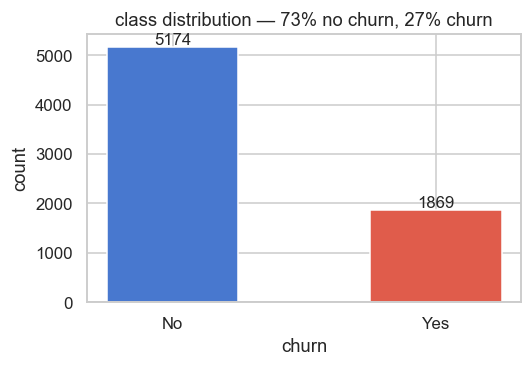

In [21]:
counts = df['Churn'].value_counts()
print(counts)
print(f'churn rate: {df["Churn_bin"].mean():.1%}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(counts.index, counts.values, color=['#4878cf', '#e05c4b'], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 40, str(val), ha='center', fontsize=11)
ax.set_xlabel('churn')
ax.set_ylabel('count')
ax.set_title('class distribution — 73% no churn, 27% churn')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/churn_distribution.png', dpi=110)
plt.show()

## 4. numeric distributions split by churn (overlapping histograms)

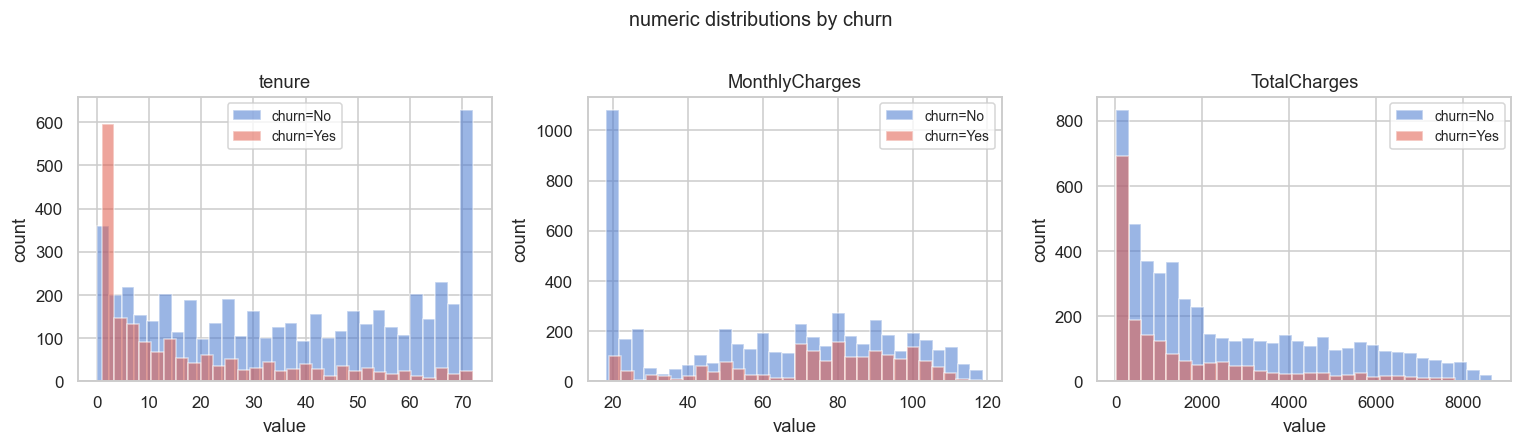

In [22]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = {'No': '#4878cf', 'Yes': '#e05c4b'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    for churn_val, grp in df.groupby('Churn'):
        grp[col].dropna().hist(
            ax=ax, bins=30, alpha=0.55,
            color=colors[churn_val], label=f'churn={churn_val}',
            edgecolor='white',
        )
    ax.set_title(col)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)
plt.suptitle('numeric distributions by churn', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/numeric_distributions.png', dpi=110)
plt.show()

## 5. boxplots — numeric features by churn

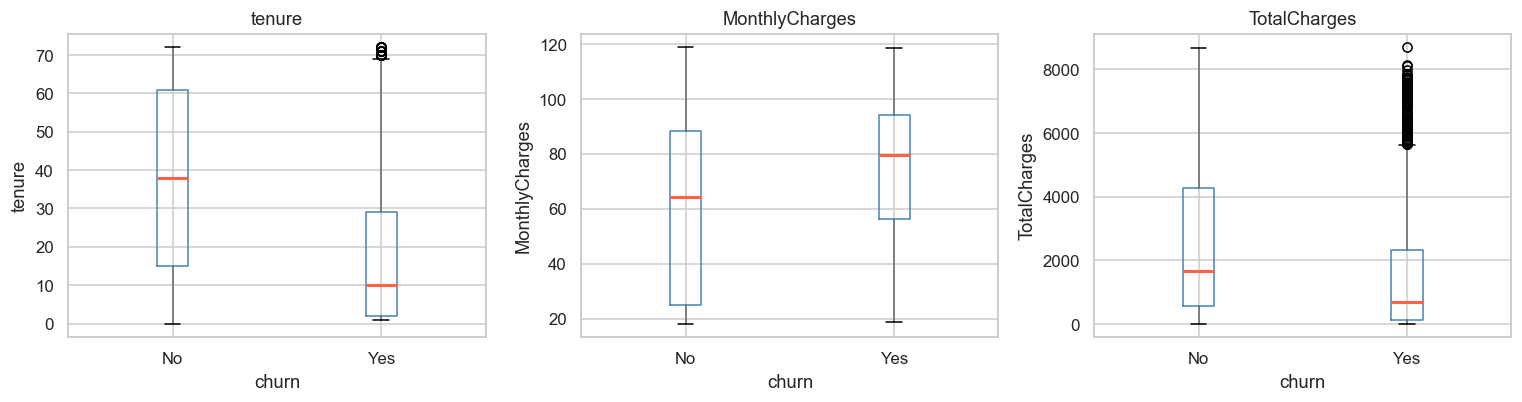

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('churn')
    ax.set_ylabel(col)
plt.suptitle('', y=0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/numeric_boxplots.png', dpi=110)
plt.show()

## 6. categorical cross-tabulations with churn

In [24]:
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(f'\n--- {col} ---')
    print(ct.round(1).rename(columns={'No': 'no churn %', 'Yes': 'churn %'}))


--- Contract ---
Churn           no churn %  churn %
Contract                           
Month-to-month        57.3     42.7
One year              88.7     11.3
Two year              97.2      2.8

--- PaymentMethod ---
Churn                      no churn %  churn %
PaymentMethod                                 
Bank transfer (automatic)        83.3     16.7
Credit card (automatic)          84.8     15.2
Electronic check                 54.7     45.3
Mailed check                     80.9     19.1

--- InternetService ---
Churn            no churn %  churn %
InternetService                     
DSL                    81.0     19.0
Fiber optic            58.1     41.9
No                     92.6      7.4


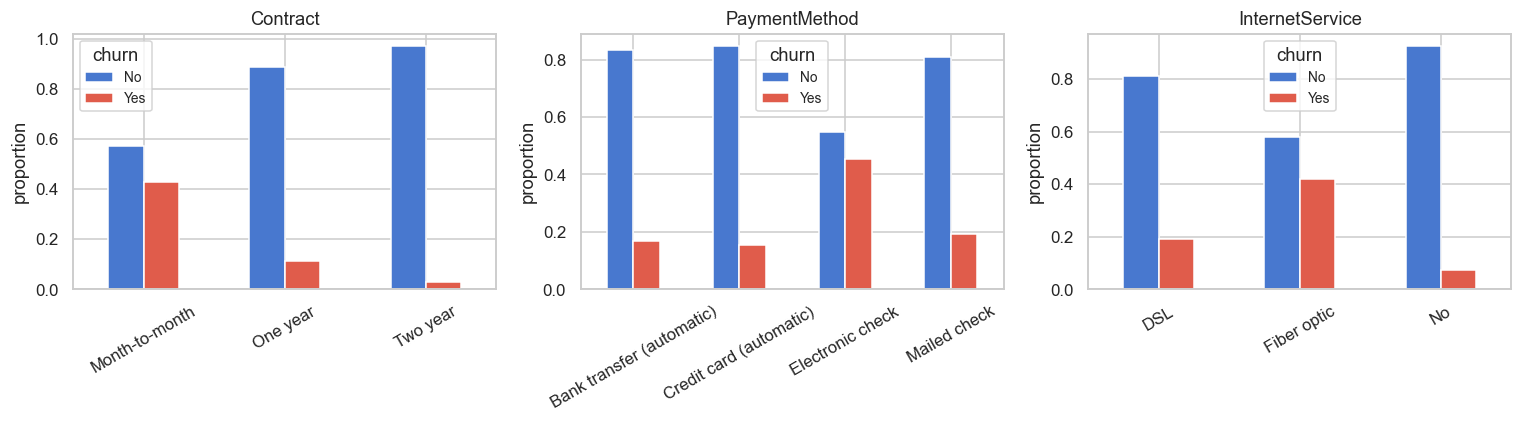

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Contract', 'PaymentMethod', 'InternetService']):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', ax=ax, color=['#4878cf', '#e05c4b'], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('proportion')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='churn', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/categorical_churn.png', dpi=110)
plt.show()

## 7. pivot heatmap — churn rate by contract × internet service

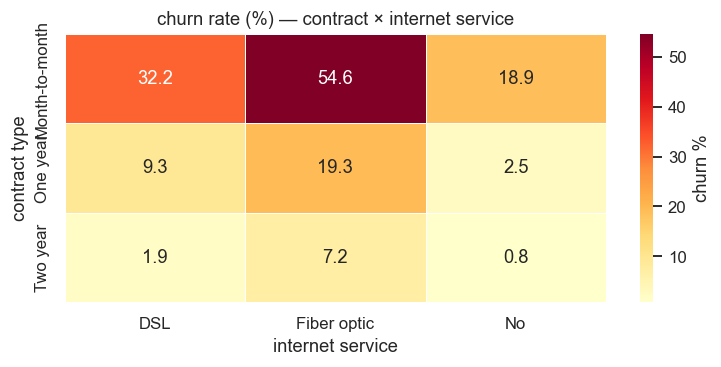

In [26]:
pivot = df.pivot_table(
    values='Churn_bin',
    index='Contract',
    columns='InternetService',
    aggfunc='mean',
) * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'churn %'},
)
ax.set_title('churn rate (%) — contract × internet service')
ax.set_ylabel('contract type')
ax.set_xlabel('internet service')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pivot_contract_internet.png', dpi=110)
plt.show()

## 8. pivot heatmap — churn rate by tenure bucket × contract

/var/folders/gk/k0653ybj3pz67w5c5_853mvw0000gn/T/ipykernel_4925/2405196889.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = df.pivot_table(


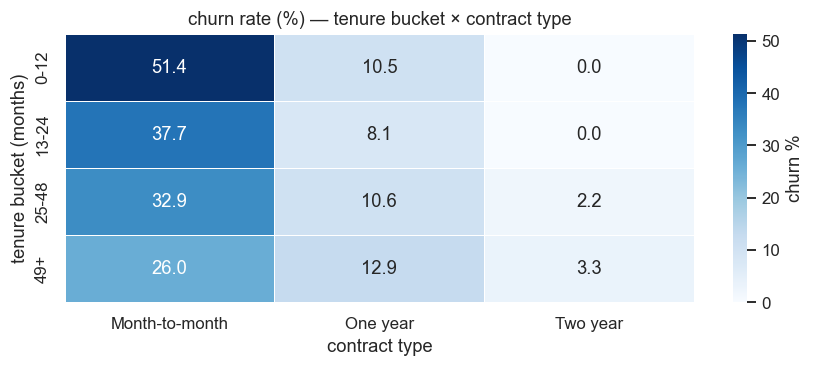

In [27]:
df['tenure_bucket'] = pd.cut(
    df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49+'], include_lowest=True,
)

pivot2 = df.pivot_table(
    values='Churn_bin',
    index='tenure_bucket',
    columns='Contract',
    aggfunc='mean',
) * 100

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    pivot2, annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'churn %'},
)
ax.set_title('churn rate (%) — tenure bucket × contract type')
ax.set_ylabel('tenure bucket (months)')
ax.set_xlabel('contract type')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pivot_tenure_contract.png', dpi=110)
plt.show()

## 9. churn rate by n_services

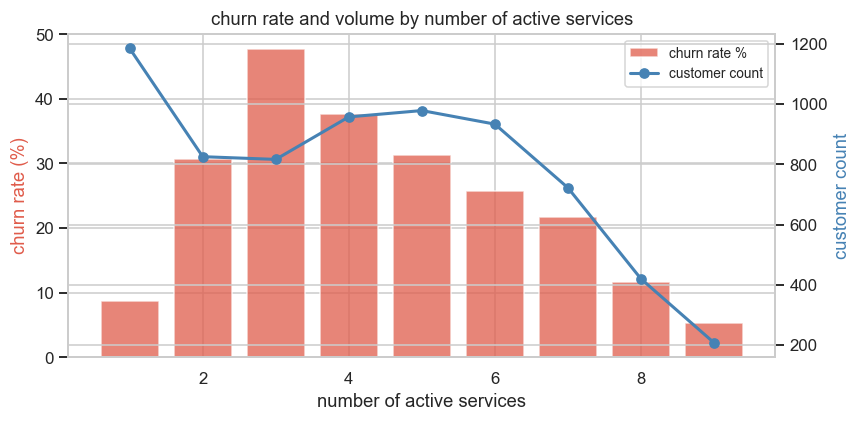

In [28]:
SERVICE_COLS = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
df['n_services'] = df[SERVICE_COLS].apply(
    lambda row: sum(v not in ('No', 'No internet service') for v in row), axis=1
)

svc_churn = df.groupby('n_services')['Churn_bin'].mean() * 100
svc_count = df.groupby('n_services')['Churn_bin'].count()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(svc_churn.index, svc_churn.values, color='#e05c4b', alpha=0.75, label='churn rate %')
ax2.plot(svc_count.index, svc_count.values, color='steelblue', marker='o', lw=2, label='customer count')
ax1.set_xlabel('number of active services')
ax1.set_ylabel('churn rate (%)', color='#e05c4b')
ax2.set_ylabel('customer count', color='steelblue')
ax1.set_title('churn rate and volume by number of active services')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/churn_by_n_services.png', dpi=110)
plt.show()

## 10. monthly charges histogram — by senior citizen status

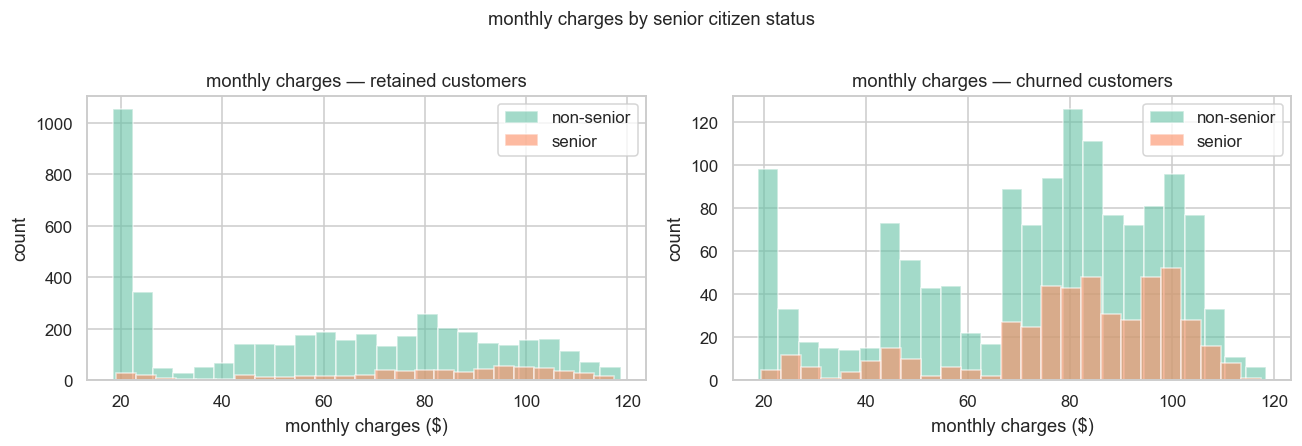

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, churn_val in zip(axes, [0, 1]):
    subset = df[df['Churn_bin'] == churn_val]
    for senior, grp in subset.groupby('SeniorCitizen'):
        label = 'senior' if senior == 1 else 'non-senior'
        grp['MonthlyCharges'].hist(
            ax=ax, bins=25, alpha=0.6, label=label, edgecolor='white',
        )
    title = 'churned customers' if churn_val == 1 else 'retained customers'
    ax.set_title(f'monthly charges — {title}')
    ax.set_xlabel('monthly charges ($)')
    ax.set_ylabel('count')
    ax.legend()

plt.suptitle('monthly charges by senior citizen status', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/monthly_charges_senior.png', dpi=110)
plt.show()

## 11. correlation heatmap — numeric features

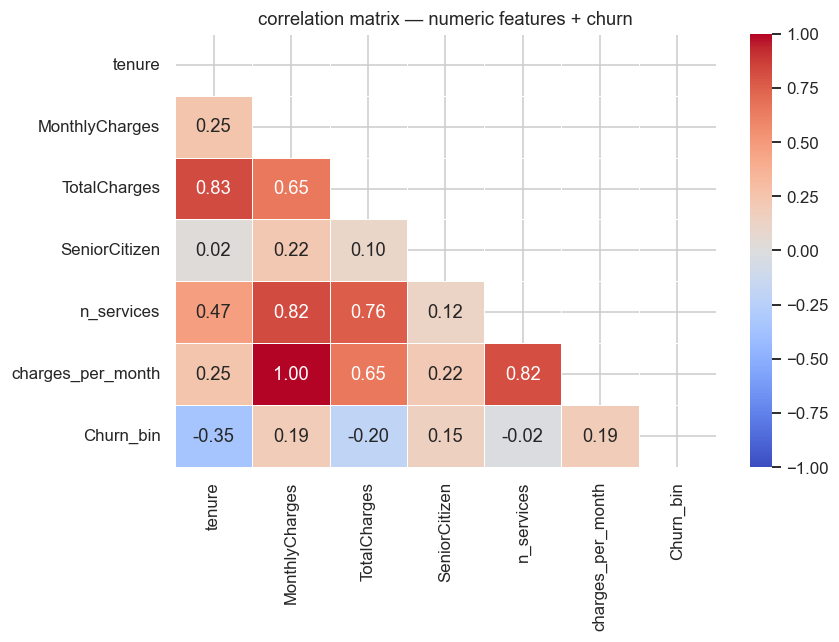

In [30]:
df['charges_per_month'] = df['TotalCharges'] / df['tenure'].clip(lower=1)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'n_services', 'charges_per_month', 'Churn_bin']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white', ax=ax,
)
ax.set_title('correlation matrix — numeric features + churn')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/correlation_heatmap.png', dpi=110)
plt.show()

## 12. churn rate by payment method × paperless billing (stacked bar)

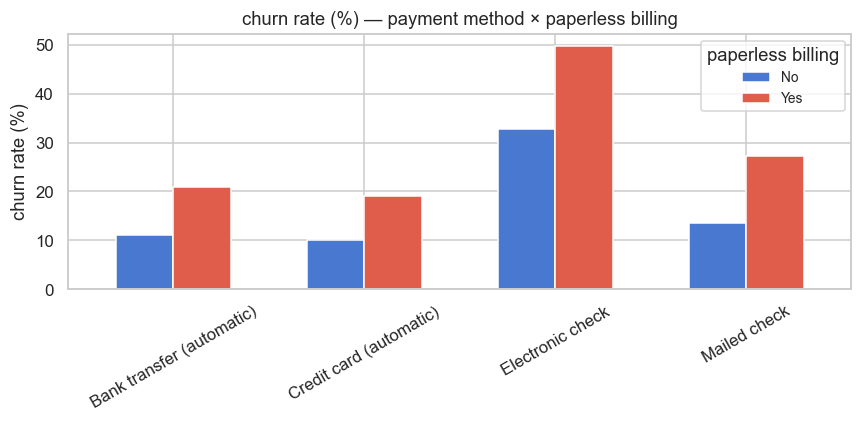

In [31]:
pivot3 = df.pivot_table(
    values='Churn_bin',
    index='PaymentMethod',
    columns='PaperlessBilling',
    aggfunc='mean',
) * 100

fig, ax = plt.subplots(figsize=(8, 4))
pivot3.plot(kind='bar', ax=ax, color=['#4878cf', '#e05c4b'], edgecolor='white', width=0.6)
ax.set_title('churn rate (%) — payment method × paperless billing')
ax.set_xlabel('')
ax.set_ylabel('churn rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='paperless billing', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/pivot_payment_paperless.png', dpi=110)
plt.show()

**insight 1 — contract type is the strongest predictor:**  
month-to-month contracts churn at ~43%, one-year at ~11%, two-year at ~3%. the pivot heatmap shows even fiber optic customers with a 2-year contract barely churn (~5%).

**insight 2 — fiber optic customers churn more, especially month-to-month:**  
fiber optic + month-to-month is the highest-risk combination (~52% churn). dsl month-to-month is ~35%. the overlap histogram shows churned customers have higher monthly charges — fiber is more expensive.

**insight 3 — electronic check payment correlates with high churn:**  
electronic check customers churn at ~45%, especially when combined with paperless billing (~46%). credit card and bank transfer auto-pay customers churn far less (~15-18%), likely because auto-pay reduces the chance of accidental cancellation.

**insight 4 — more services → lower churn (up to a point):**  
customers with 0-2 active services churn at 30-40%. those with 5+ services churn at under 20%. bundling increases switching cost. but the volume of high-service customers is smaller, so they're not the main segment to target.

**insight 5 — new customers (tenure 0-12) churn the most:**  
regardless of contract type, the 0-12 month bucket always has the highest churn rate. early intervention (calls in the first 3 months) likely has the highest ROI.